# TS7: Filtrado digital lineal de ECG (1ra parte)
# Filtros IIR

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import signal as sig
import scipy.io as sio

def plot_zplane(z, p, title='Diagrama de polos y ceros (plano z)'):
    fig, ax = plt.subplots(figsize=(5, 5))
    unit_circle = patches.Circle((0, 0), radius=1, fill=False,
                                  color='gray', linestyle='dashed', linewidth=1.5)
    ax.add_patch(unit_circle)
    ax.scatter(z.real, z.imag, marker='o', facecolors='none',
               edgecolors='steelblue', s=120, linewidth=2, label='Ceros')
    ax.scatter(p.real, p.imag, marker='x', color='crimson',
               s=120, linewidth=2.5, label='Polos')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Parte real'); ax.set_ylabel('Parte imaginaria')
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_plantilla(filter_type='', fpass=0.25, ripple=0.5, fstop=0.6, attenuation=40, fs=2):
    """
    Plotea una plantilla de diseño de filtro digital
    filter_type : 'lowpass', 'highpass', 'bandpass' o 'bandstop'
    fpass, fstop: un número (lowpass/highpass) o una tupla de 2 (bandpass/bandstop)
    ripple      : rizado máximo en banda de paso [dB]
    attenuation : atenuación mínima en banda de rechazo [dB]
    fs          : frecuencia de muestreo (define el fondo verde hasta fs/2)
    """
    xmin, xmax, ymin, ymax = plt.axis()
    # Si no se especifica el tipo, inferirlo comparando fpass y fstop
    if filter_type not in ('lowpass', 'highpass', 'bandpass', 'bandstop'):
        if isinstance(fpass, (tuple, list, np.ndarray)):
            filter_type = 'bandpass' if fstop[0] < fpass[0] else 'bandstop'
        else:
            filter_type = 'highpass' if fstop < fpass else 'lowpass'

    if filter_type == 'lowpass':
        fstop_start, fstop_end = fstop, xmax
        fpass_start, fpass_end = xmin, fpass

    elif filter_type == 'highpass':
        fstop_start, fstop_end = xmin, fstop
        fpass_start, fpass_end = fpass, xmax

    elif filter_type == 'bandpass':
        fstop_start, fstop_end   = xmin, fstop[0]
        fpass_start, fpass_end   = fpass[0], fpass[1]
        fstop2_start, fstop2_end = fstop[1], xmax

    elif filter_type == 'bandstop':
        fpass_start, fpass_end   = xmin, fpass[0]
        fstop_start, fstop_end   = fstop[0], fstop[1]
        fpass2_start, fpass2_end = fpass[1], xmax

    # Zona prohibida de rechazo: por encima de -attenuation
    plt.fill([fstop_start, fstop_end, fstop_end, fstop_start],
              [-attenuation, -attenuation, ymax, ymax],
              'lightgrey', alpha=0.4, hatch='x', lw=1, ls='--', ec='k')

    # Zona prohibida de paso: por debajo de -ripple
    plt.fill([fpass_start, fpass_start, fpass_end, fpass_end],
              [ymin, -ripple, -ripple, ymin],
              'lightgrey', alpha=0.4, hatch='x', lw=1, ls='--', ec='k', label='Plantilla')

    # Segunda zona de rechazo (bandpass) o de paso (bandstop)
    if filter_type == 'bandpass':
        plt.fill([fstop2_start, fstop2_end, fstop2_end, fstop2_start],
                  [-attenuation, -attenuation, ymax, ymax],
                  'lightgrey', alpha=0.4, hatch='x', lw=1, ls='--', ec='k')

    if filter_type == 'bandstop':
        plt.fill([fpass2_start, fpass2_start, fpass2_end, fpass2_end],
                  [ymin, -ripple, -ripple, ymin],
                  'lightgrey', alpha=0.4, hatch='x', lw=1, ls='--', ec='k')

    plt.grid(True, alpha=0.3)

    plt.axis([xmin, xmax, max(ymin, -100), max(ymax, 1)])

def graficar_respuesta_filtro(axes, w, h, fs, color, nombre):
    fase = np.unwrap(np.angle(h))
    gd = group_delay(w * 2 * np.pi / fs, fase)

    ax = axes[0]
    ax.plot(w, 20 * np.log10(np.abs(h) + 1e-12), linewidth=1.8, color=color, label=nombre)
    ax.set_ylabel("Amplitud [dB]")
    ax.set_title("Módulo de la respuesta en frecuencia")

    ax = axes[1]
    ax.plot(w, np.degrees(fase), linewidth=1.8, color=color, label=nombre)
    ax.set_ylabel("Fase [°]")
    ax.set_title("Fase")
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    ax.plot(w, gd, linewidth=1.8, color=color, label=nombre)
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("Retardo de grupo [muestras]")
    ax.set_title("Retardo de grupo")
    ax.grid(True, alpha=0.3)


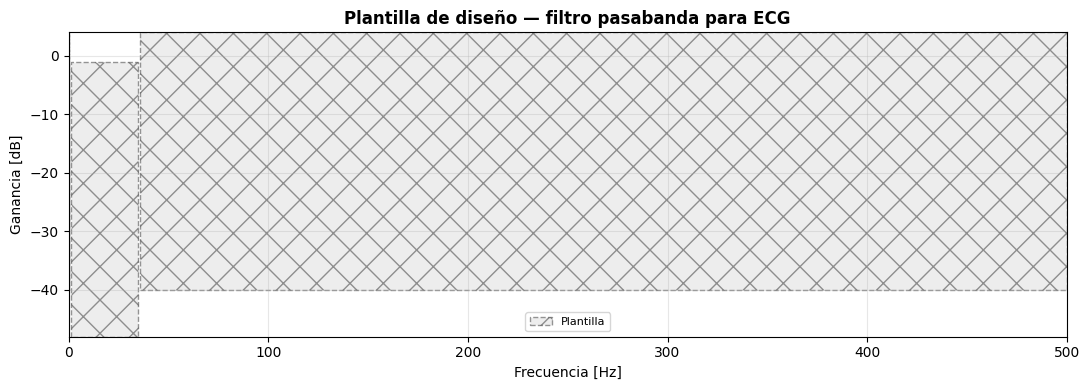

In [2]:
# ECG
fs            = 1000          # Hz
nyq_frec      = fs/2        # Hz
N_freqz = fs

mat = sio.loadmat('ecg.mat')
ecg_lead = mat['ecg_lead'].ravel().astype(float)
qrs_pattern1 = mat['qrs_pattern1'].ravel()
heartbeat_pat1 = mat['heartbeat_pattern1'].ravel()
heartbeat_pat2 = mat['heartbeat_pattern2'].ravel()
qrs_detections = mat['qrs_detections'].ravel()

cant_muestras = len(ecg_lead)
t = np.arange(cant_muestras) / fs

# Plantilla
ripple     = 1
atenuacion = 40

ws1 = 0.1
wp1 = 1.0
wp2 = 35.0
ws2 = 36.0

frecs     = np.array([0.0, ws1, wp1, wp2, ws2, nyq_frec]) / nyq_frec
gains_dB  = np.array([-atenuacion, -atenuacion, -ripple, -ripple, -atenuacion, -atenuacion])
gains_lin = 10 ** (gains_dB / 20)

# Ploteo de la plantilla
fig, ax = plt.subplots(figsize=(11, 4))
ax.set_xlim(0, nyq_frec)
ax.set_ylim(-atenuacion - 8, 4)

plot_plantilla(filter_type='bandpass',
               fpass=(wp1, wp2), ripple=ripple,
               fstop=(ws1, ws2), attenuation=atenuacion,
               fs=fs)

ax.set_xlabel('Frecuencia [Hz]'); ax.set_ylabel('Ganancia [dB]')
ax.set_title('Plantilla de diseño — filtro pasabanda para ECG',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='lower center')
plt.tight_layout(); plt.show()


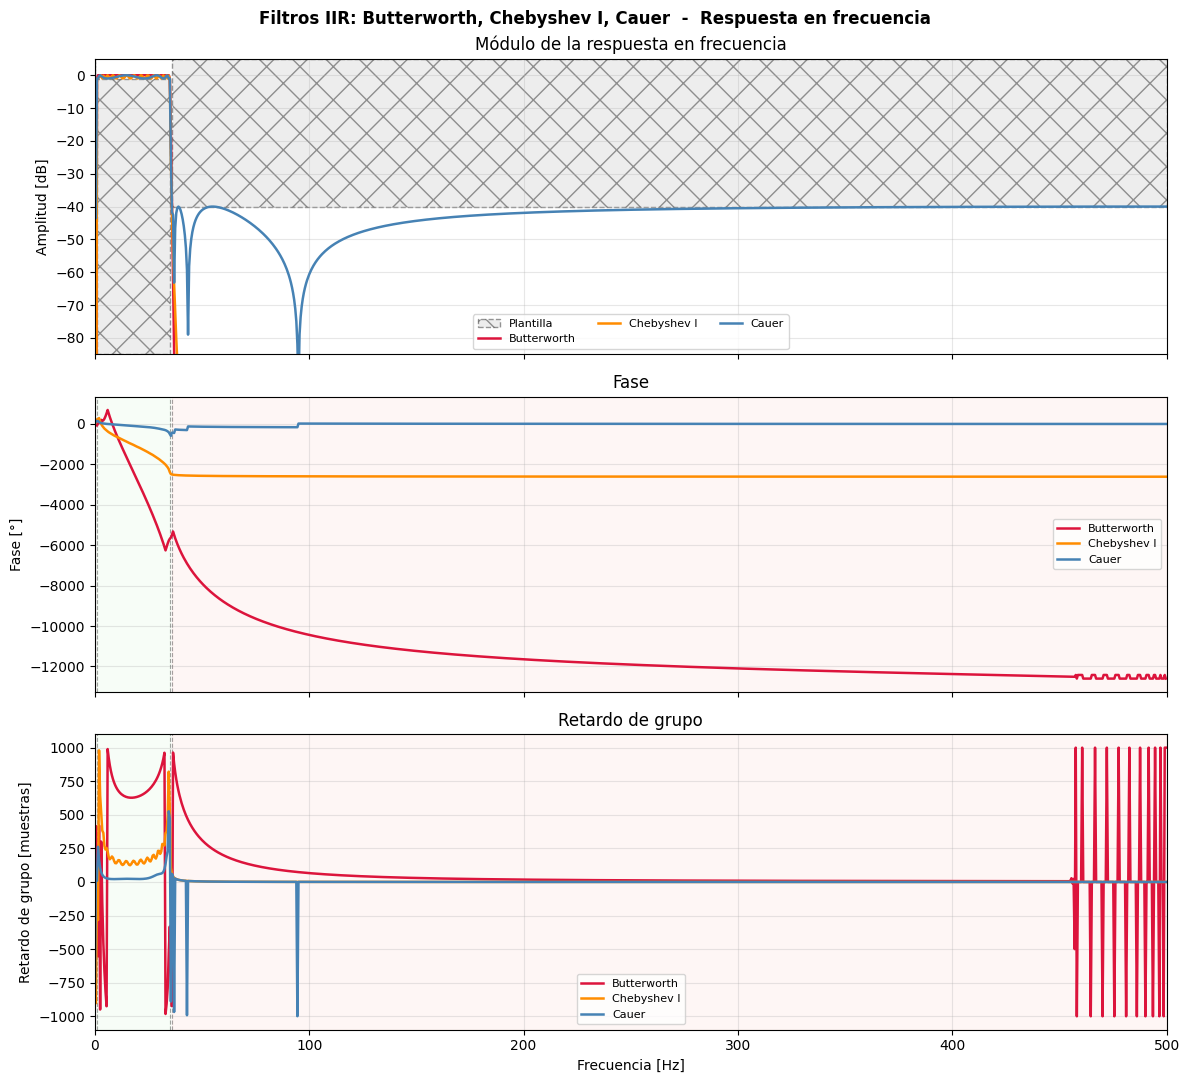

In [3]:
# Butterworth
sos_butt = sig.iirdesign(wp=[wp1, wp2], ws=[ws1, ws2], gpass=ripple, gstop=atenuacion,
                          analog=False, fs=fs, ftype='butter', output='sos')

# Chebyshev tipo I
sos_cheb1 = sig.iirdesign(wp=[wp1, wp2], ws=[ws1, ws2], gpass=ripple, gstop=atenuacion,
                           analog=False, fs=fs, ftype='cheby1', output='sos')

# Cauer
sos_cauer = sig.iirdesign(wp=[wp1, wp2], ws=[ws1, ws2], gpass=ripple, gstop=atenuacion,
                           analog=False, fs=fs, ftype='cauer', output='sos')

filtros = {
    'Butterworth' : (sos_butt,  'crimson'),
    'Chebyshev I' : (sos_cheb1, 'darkorange'),
    'Cauer':(sos_cauer, 'steelblue'),
}

def group_delay(freq, phase):
    groupDelay = -np.diff(phase) / np.diff(freq)
    return np.append(groupDelay, groupDelay[-1])

# Módulo, fase, retardo de grupo
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
fig.suptitle("Filtros IIR: Butterworth, Chebyshev I, Cauer  -  Respuesta en frecuencia",
             fontsize=12, fontweight='bold')
for ax in axes[1:]:
    ax.axvspan(0, ws1, alpha=0.07, color='salmon')
    ax.axvspan(ws2, nyq_frec, alpha=0.07, color='salmon')
    ax.axvspan(wp1, wp2, alpha=0.07, color='lightgreen')
    for fv in [ws1, wp1, wp2, ws2]:
        ax.axvline(fv, color='dimgray', linestyle='--', linewidth=0.8, alpha=0.6)

ax = axes[0]
plt.sca(ax)
ax.set_xlim(0, nyq_frec)
ax.set_ylim(-85, 5)
plot_plantilla(filter_type='bandpass', fpass=(wp1, wp2), ripple=ripple,
              fstop=(ws1, ws2), attenuation=atenuacion, fs=fs)

for name, (sos, color) in filtros.items():
    w, h = sig.freqz_sos(sos, worN=N_freqz, fs=fs)
    graficar_respuesta_filtro(axes, w, h, fs, color, name)

axes[0].legend(fontsize=8, loc='lower center', ncol=3)
axes[1].legend(fontsize=8)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:1230: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  b, a = normalize(b, a)


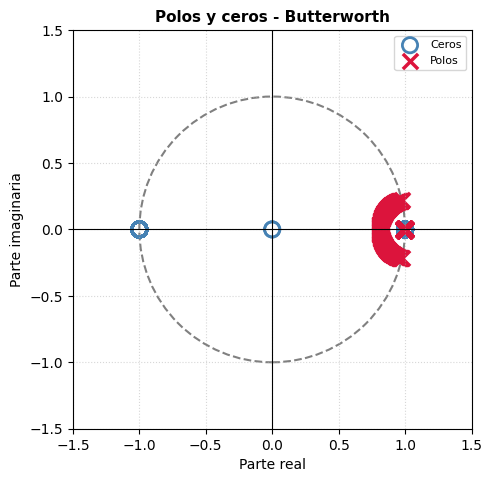

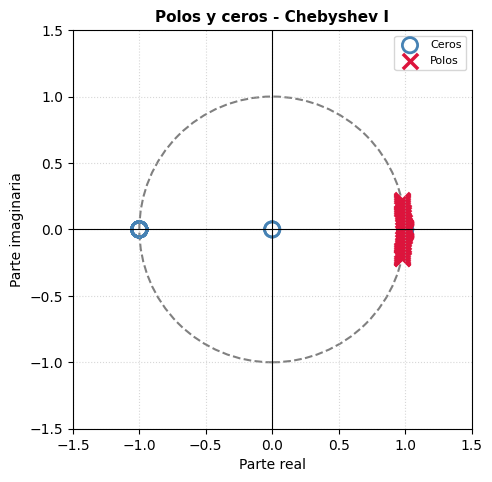

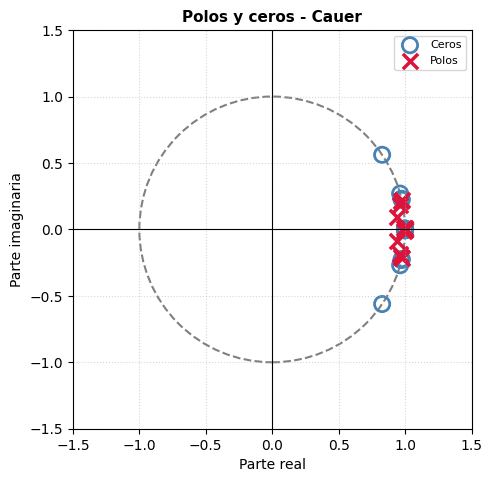

In [4]:
for name, (sos, _) in filtros.items():
    z, p, k = sig.sos2zpk(sos)
    plot_zplane(z, p, title=f'Polos y ceros - {name}')


In [5]:
ecg_f_butt  = sig.sosfiltfilt(sos_butt,  ecg_lead)
ecg_f_cheb1 = sig.sosfiltfilt(sos_cheb1, ecg_lead)
ecg_f_cauer = sig.sosfiltfilt(sos_cauer, ecg_lead)

salidas = {
    'Butterworth' : (ecg_f_butt,  'crimson'),
    'Chebyshev I' : (ecg_f_cheb1, 'darkorange'),
    'Cauer': (ecg_f_cauer, 'steelblue'),
}


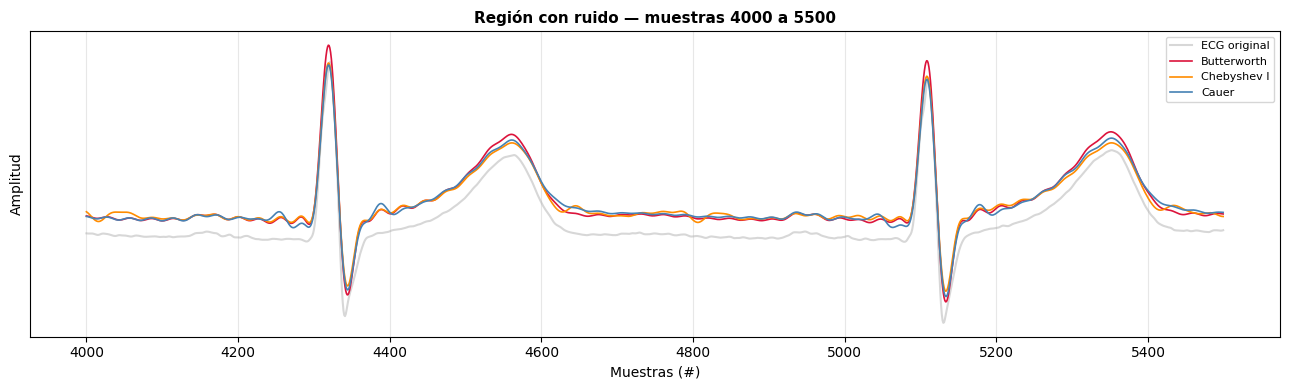

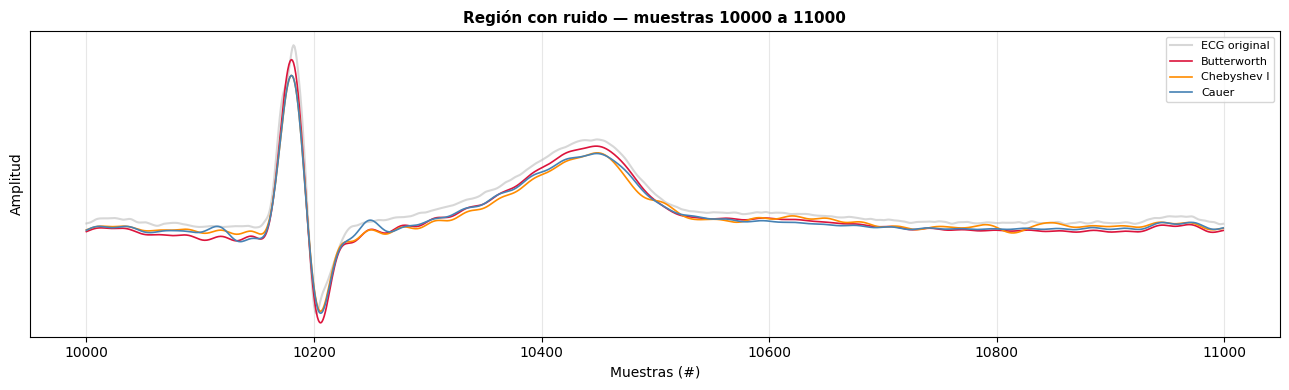

In [6]:
regs_interes = ([4000, 5500],
                [10000, 11000])

for ii in regs_interes:
    zoom_region = np.arange(max(0, ii[0]),
                             min(cant_muestras, ii[1]), dtype='uint')

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(zoom_region, ecg_lead[zoom_region],
            color='lightgray', linewidth=1.5, alpha=0.9, label='ECG original', zorder=1)
    for name, (ecg_f, color) in salidas.items():
        ax.plot(zoom_region, ecg_f[zoom_region],
                color=color, linewidth=1.2, label=name, zorder=2)
    ax.set_title(f'Región con ruido — muestras {ii[0]} a {ii[1]}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Muestras (#)'); ax.set_ylabel('Amplitud')
    ax.set_yticks([])
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


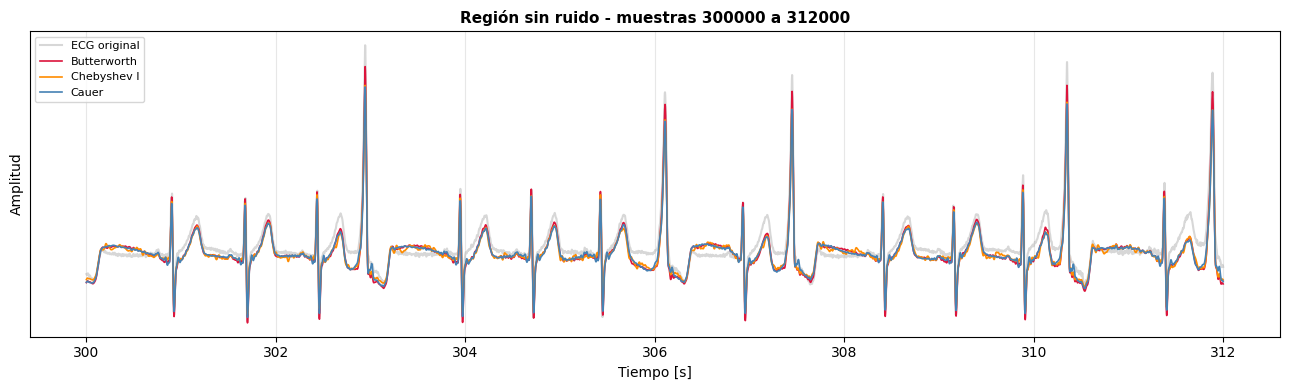

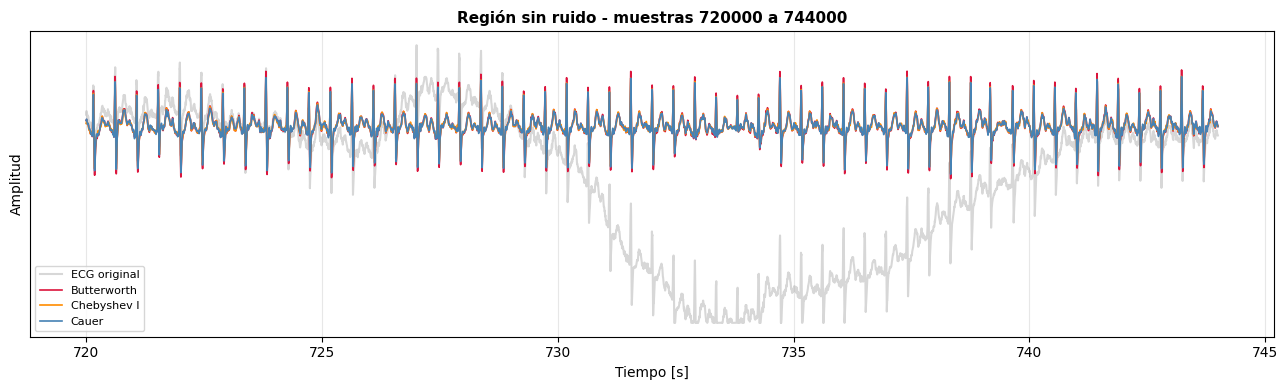

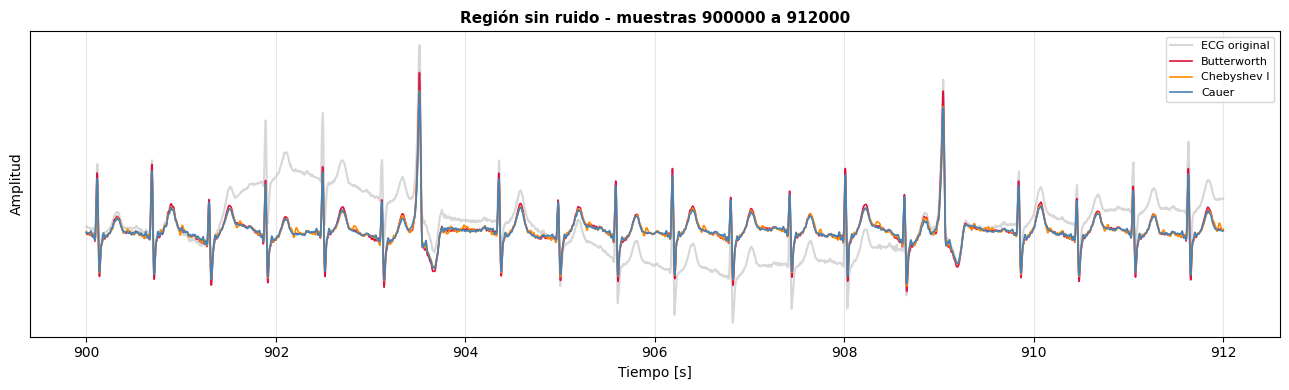

In [7]:
regs_interes = (
    np.array([5,    5.2 ]) * 60 * fs,
    np.array([12,  12.4 ]) * 60 * fs,
    np.array([15,  15.2 ]) * 60 * fs,
)

for ii in regs_interes:
    zoom_region = np.arange(max(0, int(ii[0])),
                             min(cant_muestras, int(ii[1])), dtype='uint')

    if len(zoom_region) == 0:
        print(f"Región {ii/fs/60} min fuera del rango "
              f"(señal tiene {cant_muestras/fs/60:.1f} min)")
        continue

    t_zoom      = zoom_region / fs

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(t_zoom, ecg_lead[zoom_region],
            color='lightgray', linewidth=1.5, alpha=0.9, label='ECG original', zorder=1)
    for name, (ecg_f, color) in salidas.items():
        ax.plot(t_zoom, ecg_f[zoom_region],
                color=color, linewidth=1.2, label=name, zorder=2)
    ax.set_title(f'Región sin ruido - muestras {int(ii[0])} a {int(ii[1])}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Tiempo [s]'); ax.set_ylabel('Amplitud')
    ax.set_yticks([])
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


# Filtros FIR

In [8]:
def demora_grupo_fir(h):
    return (len(h) - 1) / 2


def filtrar_fir_fase_lineal(h, x):
    y = sig.lfilter(h, 1.0, x)
    demora = int(round((len(h) - 1) / 2))
    y_comp = np.roll(y, -demora)
    return y_comp, demora

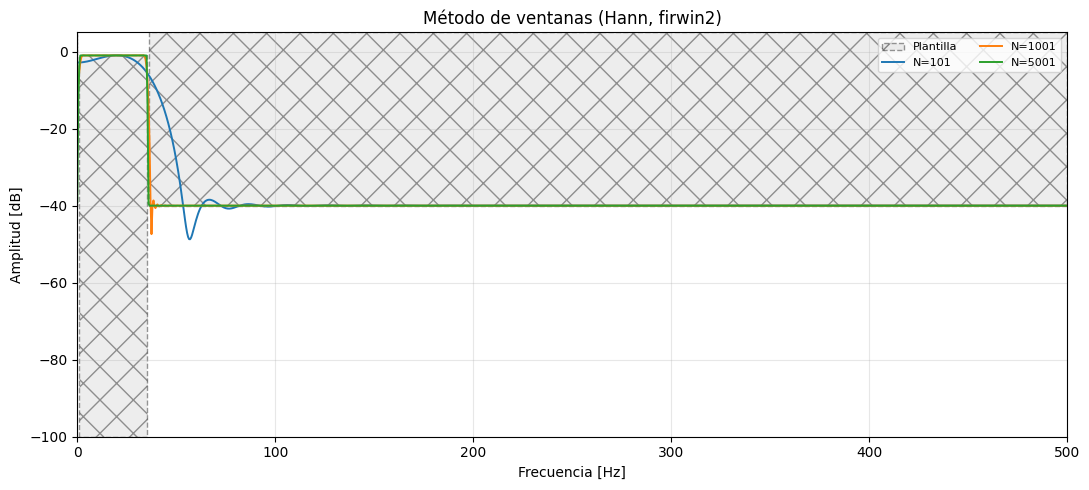

N elegido = 5001


In [9]:
# ============================================================
# Método de ventanas
# ============================================================
ws1_ajustada = ws1+0.15
wp1_ajustada = wp1+0.3
wp2_ajustada = wp2+0.24
ws2_ajustada = ws2-0.5

frecs     = [0.0, ws1_ajustada, wp1_ajustada, wp2_ajustada, ws2_ajustada, nyq_frec]
gains_dB  = [-atenuacion, -atenuacion, -ripple, -ripple, -atenuacion, -atenuacion]
gains_lin = 10 ** (np.array(gains_dB) / 20)

N_candidatos = [101, 1001, 5001]

resultados_win = {}
for N in N_candidatos:
    if N % 2 == 0:
        N += 1
    resultados_win[N] = sig.firwin2(N, frecs, gains_lin, window='hann', fs=fs)

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_xlim(0, nyq_frec)
ax.set_ylim(-100, 5)
plot_plantilla(filter_type='bandpass', fpass=(wp1, wp2), ripple=ripple,
               fstop=(ws1, ws2), attenuation=atenuacion, fs=fs)

for i, (N, h) in enumerate(resultados_win.items()):
    w, H = sig.freqz(h, worN=N_freqz, fs=fs)
    ax.plot(w, 20 * np.log10(np.abs(H) + 1e-12), linewidth=1.4, label=f'N={N}')

ax.set_xlabel("Frecuencia [Hz]"); ax.set_ylabel("Amplitud [dB]")
ax.set_title("Método de ventanas (Hann, firwin2)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

h_win = resultados_win[list(resultados_win.keys())[-1]]

print(f"N elegido = {len(h_win)}")

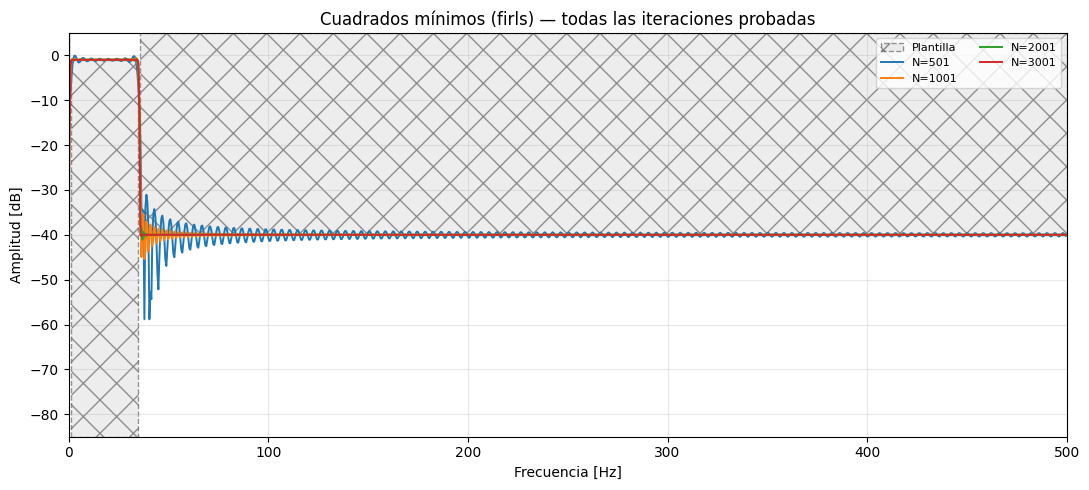

N elegido = 3001


In [10]:
# ============================================================
# Cuadrados mínimos
# ============================================================

ws1_ajustada = ws1-0.05
wp1_ajustada = wp1+0.37
wp2_ajustada = wp2-0.2
ws2_ajustada = ws2-0.05

frecs     = [0.0, ws1_ajustada, wp1_ajustada, wp2_ajustada, ws2_ajustada, nyq_frec]
gains_dB  = [-atenuacion, -atenuacion, -ripple, -ripple, -atenuacion, -atenuacion]
gains_lin = 10 ** (np.array(gains_dB) / 20)

delta_p = 1 - 10 ** (-ripple / 20)
delta_s = 10 ** (-atenuacion / 20)
peso_paso    = 1 / delta_p
peso_rechazo = 1 / delta_s
pesos_fls    = [peso_rechazo, peso_paso, peso_rechazo]

N_candidatos = [501, 1001, 2001, 3001]

resultados_firls = {}
for N in N_candidatos:
    if N % 2 == 0:
        N += 1
    try:
        resultados_firls[N] = sig.firls(N, frecs, gains_lin, weight=pesos_fls, fs=fs)
    except ValueError:
        continue

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_xlim(0, nyq_frec)
ax.set_ylim(-85, 5)
plot_plantilla(filter_type='bandpass', fpass=(wp1_ajustada, wp2_ajustada), ripple=ripple,
               fstop=(ws1_ajustada, ws2_ajustada), attenuation=atenuacion, fs=fs)

for i, (N, h) in enumerate(resultados_firls.items()):
    w, H = sig.freqz(h, worN=N_freqz, fs=fs)
    ax.plot(w, 20 * np.log10(np.abs(H) + 1e-12), linewidth=1.4, label=f'N={N}')

ax.set_xlabel("Frecuencia [Hz]"); ax.set_ylabel("Amplitud [dB]")
ax.set_title("Cuadrados mínimos (firls) — todas las iteraciones probadas")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

h_firls = resultados_firls[list(resultados_firls.keys())[-1]]

print(f"N elegido = {len(h_firls)}")

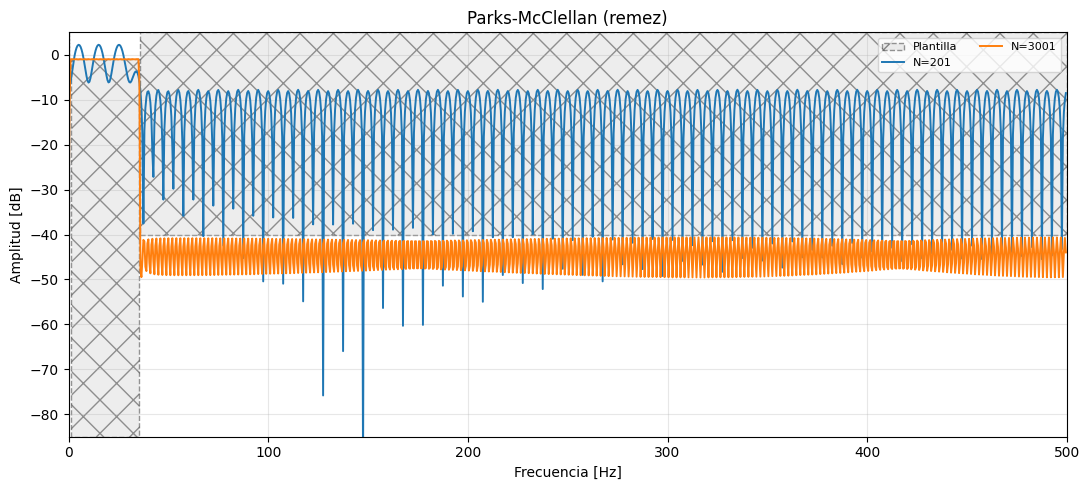

N elegido = 3001


In [11]:
# ============================================================
# Parks-McClellan / Remez
# ============================================================

ws1_ajustada = ws1
wp1_ajustada = wp1
wp2_ajustada = wp2+0.1
ws2_ajustada = ws2-0.05

frecs     = [0.0, ws1_ajustada, wp1_ajustada, wp2_ajustada, ws2_ajustada, nyq_frec]
gains_dB  = [-atenuacion, -atenuacion, -ripple, -ripple, -atenuacion-4, -atenuacion-4]
gains_lin = 10 ** (np.array(gains_dB) / 20)

N_candidatos = [201, 3001]

resultados_remez = {}
for N in N_candidatos:
        resultados_remez[N] = sig.remez(N, frecs, gains_lin[::2], fs=fs)

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_xlim(0, nyq_frec)
ax.set_ylim(-85, 5)
plot_plantilla(filter_type='bandpass', fpass=(wp1_ajustada, wp2_ajustada), ripple=ripple,
               fstop=(ws1_ajustada, ws2_ajustada), attenuation=atenuacion, fs=fs)

for i, (N, h) in enumerate(resultados_remez.items()):
    w, H = sig.freqz(h, worN=N_freqz, fs=fs)
    ax.plot(w, 20 * np.log10(np.abs(H) + 1e-12), linewidth=1.4, label=f'N={N}')

ax.set_xlabel("Frecuencia [Hz]"); ax.set_ylabel("Amplitud [dB]")
ax.set_title("Parks-McClellan (remez)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

h_remez = resultados_remez[list(resultados_remez.keys())[-1]]

print(f"N elegido = {len(h_remez)}")

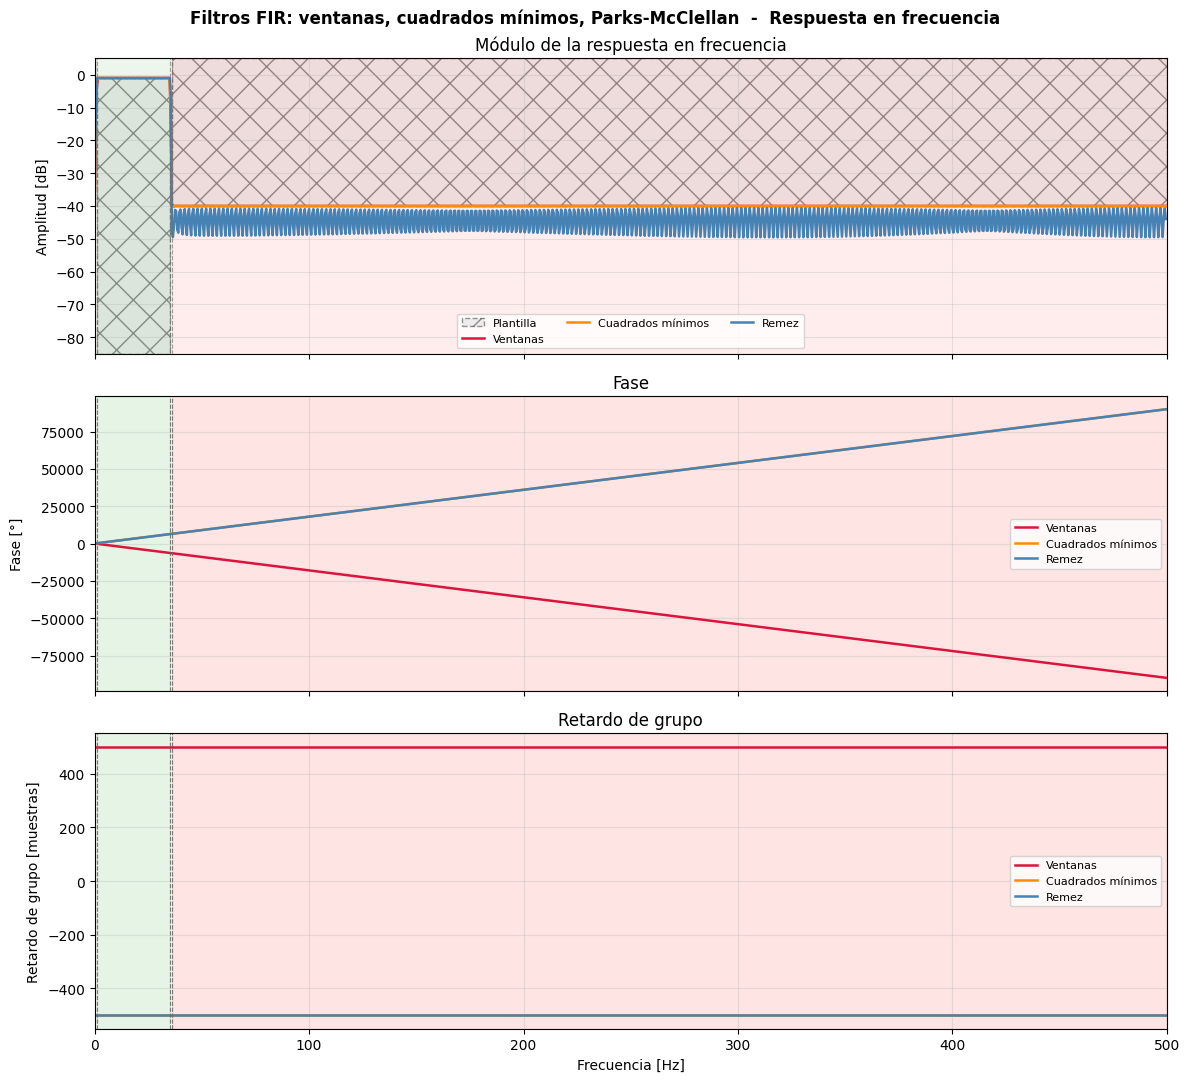

In [12]:
# ============================================================
# Comparación de los 3 FIR contra la plantilla de diseño
# ============================================================
filtros_fir = {
    'Ventanas'        : (h_win, 'crimson'),
    'Cuadrados mínimos'        : (h_firls,  'darkorange'),
    'Remez': (h_remez,  'steelblue'),
}

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
fig.suptitle("Filtros FIR: ventanas, cuadrados mínimos, Parks-McClellan  -  "
             "Respuesta en frecuencia", fontsize=12, fontweight='bold')

# Fase y retardo de grupo: sombreado simple de bandas
for ax in axes[1:]:
    ax.axvspan(0,   ws1,      alpha=0.07, color='salmon')
    ax.axvspan(ws2, nyq_frec, alpha=0.07, color='salmon')
    ax.axvspan(wp1, wp2,      alpha=0.07, color='lightgreen')
    for fv in [ws1, wp1, wp2, ws2]:
        ax.axvline(fv, color='dimgray', linestyle='--', linewidth=0.8, alpha=0.6)

# Módulo: plot_plantilla como máscara de diseño
ax = axes[0]
plt.sca(ax)
ax.set_xlim(0, nyq_frec)
ax.set_ylim(-85, 5)
plot_plantilla(filter_type='bandpass', fpass=(wp1, wp2), ripple=ripple,
               fstop=(ws1, ws2), attenuation=atenuacion, fs=fs)
ax.set_ylabel("Amplitud [dB]")
ax.set_title("Módulo de la respuesta en frecuencia")
ax.legend(fontsize=8, loc='lower center', ncol=2)

for name, (h, color) in filtros_fir.items():
    ax = axes[0]
    w, H = sig.freqz(h, worN=N_freqz, fs=fs)
    fase = np.unwrap(np.angle(H))
    gd = group_delay(w * 2*np.pi / fs, fase)
    ax.plot(w, 20*np.log10(np.abs(H) + 1e-12), linewidth=1.8, color=color, label=name)
    ax.set_ylabel("Amplitud [dB]")
    ax.set_title("Módulo de la respuesta en frecuencia")
    ax.legend(fontsize=8, loc='lower center', ncol=3)

    ax = axes[1]
    ax.plot(w, np.degrees(fase), linewidth=1.8, color=color, label=name)
    ax.set_ylabel("Fase [°]")
    ax.set_title("Fase")
    ax.legend(fontsize=8);
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    ax.plot(w, gd, linewidth=1.8, color=color, label=name)
    ax.set_xlabel("Frecuencia [Hz]")
    ax.set_ylabel("Retardo de grupo [muestras]")
    ax.set_title("Retardo de grupo")
    ax.legend(fontsize=8);
    ax.grid(True, alpha=0.3)

for ax in axes[0:]:
    ax.axvspan(0, ws1, alpha=0.07, color='red')
    ax.axvspan(ws2, nyq_frec, alpha=0.07, color='red')
    ax.axvspan(wp1, wp2, alpha=0.07, color='green')
    for fv in [ws1, wp1, wp2, ws2]:
        ax.axvline(fv, color='dimgray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.tight_layout();
plt.show()


In [13]:
# Aplicación de los 3 FIR a la señal de ECG completa (fase lineal
# compensada)
salidas_fir = {}
for nombre, (h, color) in filtros_fir.items():
    y_comp, demora = filtrar_fir_fase_lineal(h, ecg_lead)
    salidas_fir[nombre] = (y_comp, color, demora)


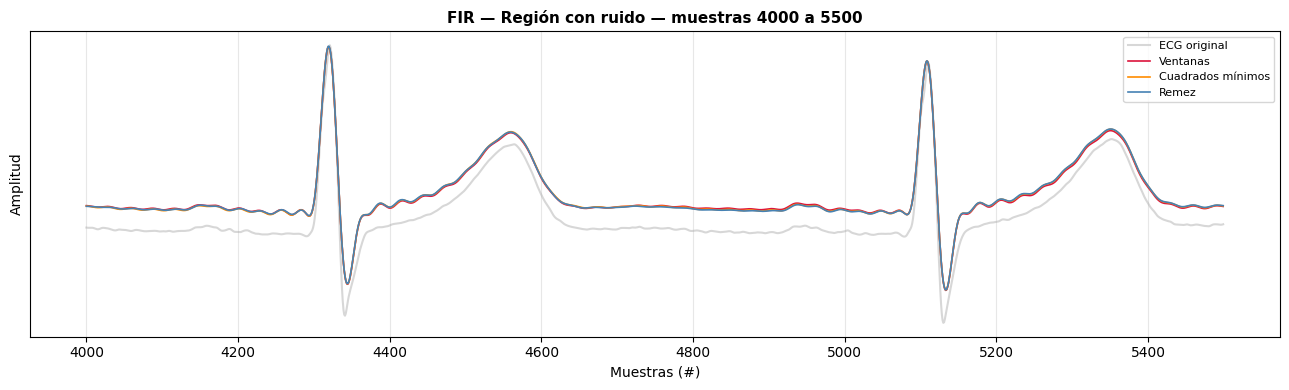

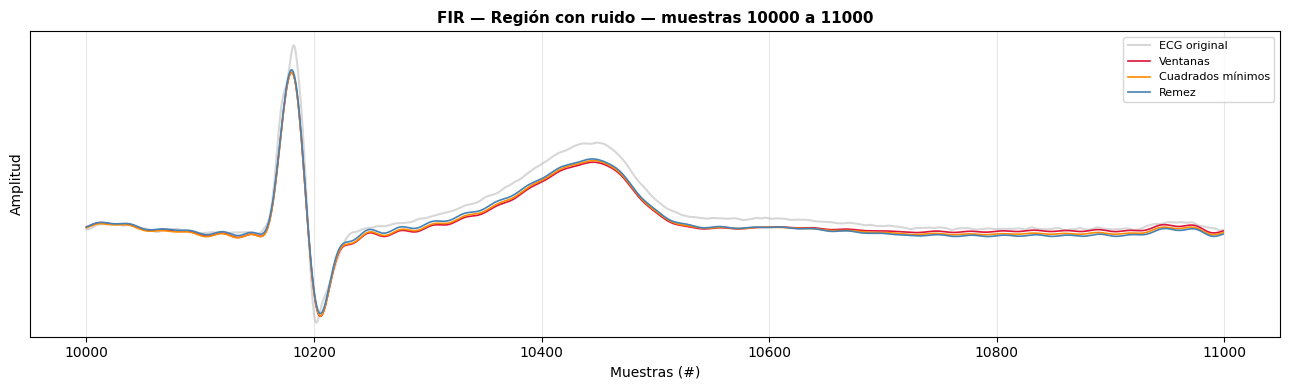

In [14]:
# 1) Verificación de que filtra las señales interferentes
regs_interes = ([4000, 5500],
                [10000, 11000])

for ii in regs_interes:
    zoom_region = np.arange(max(0, ii[0]),
                             min(cant_muestras, ii[1]), dtype='uint')

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(zoom_region, ecg_lead[zoom_region],
            color='lightgray', linewidth=1.5, alpha=0.9, label='ECG original', zorder=1)
    for nombre, (ecg_f, color, _) in salidas_fir.items():
        ax.plot(zoom_region, ecg_f[zoom_region],
                color=color, linewidth=1.2, label=nombre, zorder=2)
    ax.set_title(f'FIR — Región con ruido — muestras {ii[0]} a {ii[1]}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Muestras (#)'); ax.set_ylabel('Amplitud')
    ax.set_yticks([])
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


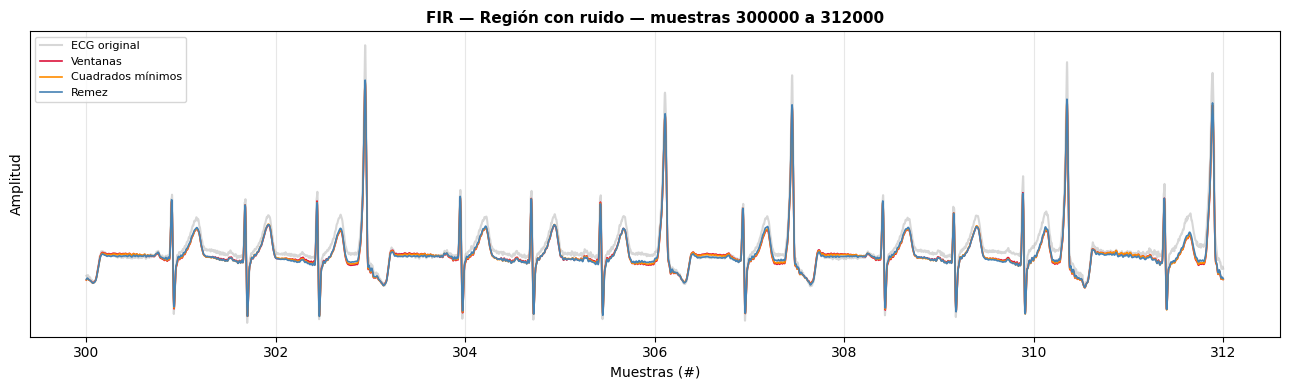

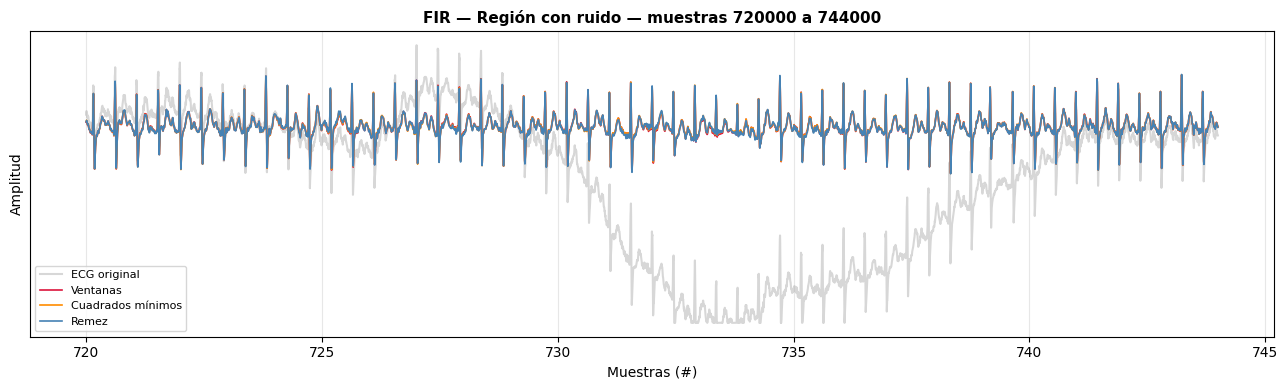

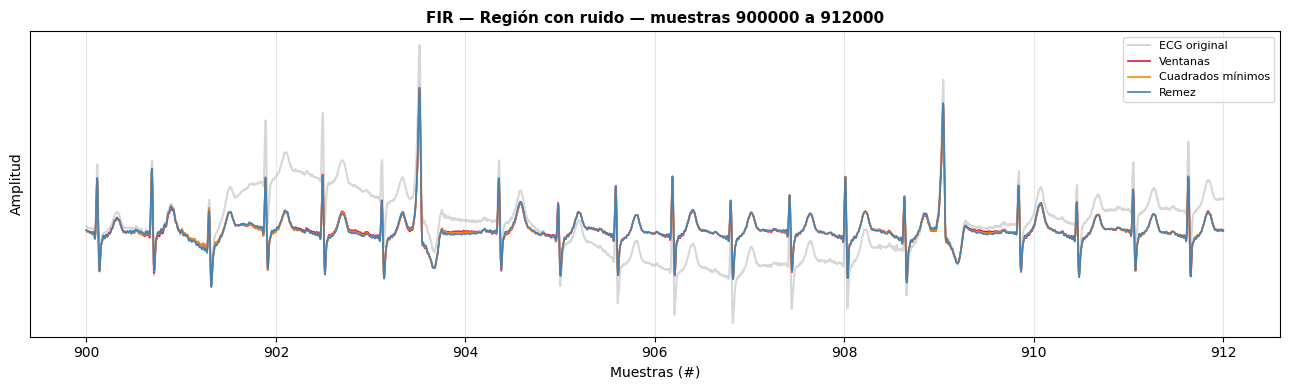

In [15]:
regs_interes = (
    np.array([5,    5.2 ]) * 60 * fs,
    np.array([12,  12.4 ]) * 60 * fs,
    np.array([15,  15.2 ]) * 60 * fs,
)

for ii in regs_interes:
    zoom_region = np.arange(max(0, int(ii[0])),
                             min(cant_muestras, int(ii[1])), dtype='uint')

    if len(zoom_region) == 0:
        print(f"Región {ii/fs/60} min fuera del rango "
              f"(señal tiene {cant_muestras/fs/60:.1f} min)")
        continue

    t_zoom    = zoom_region / fs
    t_ini_min = ii[0] / (60 * fs)
    t_fin_min = ii[1] / (60 * fs)

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(t_zoom, ecg_lead[zoom_region],
            color='lightgray', linewidth=1.5, alpha=0.9, label='ECG original', zorder=1)
    for nombre, (ecg_f, color, _) in salidas_fir.items():
        ax.plot(t_zoom, ecg_f[zoom_region],
                color=color, linewidth=1.2, label=nombre, zorder=2)
    ax.set_title(f'FIR — Región con ruido — muestras {int(ii[0])} a {int(ii[1])}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Muestras (#)'); ax.set_ylabel('Amplitud')
    ax.set_yticks([])
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
